In [ ]:
!pip install understatapi pandas --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.7/537.7 kB 9.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.1/138.1 kB 12.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
blobfile 3.2.0 requires urllib3>

In [ ]:
import pandas as pd
import understatapi

client = understatapi.UnderstatClient()

league = client.league(league='EPL')
matches = league.get_match_data(season='2025')

df = pd.DataFrame(matches)

In [ ]:
shot_data = client.match(match='29138').get_shot_data()
shot_data

{'h': [{'id': '686609',
   'minute': '14',
   'result': 'MissedShots',
   'X': '0.9369999694824219',
   'Y': '0.4929999923706055',
   'xG': '0.47701871395111084',
   'player': 'Evanilson',
   'h_a': 'h',
   'player_id': '12963',
   'situation': 'OpenPlay',
   'season': '2025',
   'shotType': 'RightFoot',
   'match_id': '29138',
   'h_team': 'Bournemouth',
   'a_team': 'Manchester City',
   'h_goals': '1',
   'a_goals': '1',
   'date': '2026-05-19 18:30:00',
   'player_assisted': 'Marcus Tavernier',
   'lastAction': 'Cross'},
  {'id': '686613',
   'minute': '38',
   'result': 'Goal',
   'X': '0.8530000305175781',
   'Y': '0.64',
   'xG': '0.06357273459434509',
   'player': 'Eli Junior Kroupi',
   'h_a': 'h',
   'player_id': '11504',
   'situation': 'OpenPlay',
   'season': '2025',
   'shotType': 'RightFoot',
   'match_id': '29138',
   'h_team': 'Bournemouth',
   'a_team': 'Manchester City',
   'h_goals': '1',
   'a_goals': '1',
   'date': '2026-05-19 18:30:00',
   'player_assisted': 'Ad

In [ ]:
type(shot_data)

dict

In [ ]:
shot_data.keys()

dict_keys(['h', 'a'])

In [ ]:
import pandas as pd

df = pd.DataFrame(shot_data['h'] + shot_data['a'])

df[['X','Y','xG','minute']] = df[['X','Y','xG','minute']].astype(float)

df.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,686609,14.0,MissedShots,0.937,0.493,0.477019,Evanilson,h,12963,OpenPlay,2025,RightFoot,29138,Bournemouth,Manchester City,1,1,2026-05-19 18:30:00,Marcus Tavernier,Cross
1,686613,38.0,Goal,0.853,0.640,0.063573,Eli Junior Kroupi,h,11504,OpenPlay,2025,RightFoot,29138,Bournemouth,Manchester City,1,1,2026-05-19 18:30:00,Adrien Truffert,Pass
2,686615,48.0,BlockedShot,0.819,0.293,0.033257,Rayan,h,14395,OpenPlay,2025,LeftFoot,29138,Bournemouth,Manchester City,1,1,2026-05-19 18:30:00,Alex Scott,Chipped
3,686616,51.0,BlockedShot,0.901,0.564,0.135844,Evanilson,h,12963,OpenPlay,2025,RightFoot,29138,Bournemouth,Manchester City,1,1,2026-05-19 18:30:00,Adrien Truffert,Pass
4,686618,59.0,MissedShots,0.811,0.501,0.103907,Eli Junior Kroupi,h,11504,OpenPlay,2025,RightFoot,29138,Bournemouth,Manchester City,1,1,2026-05-19 18:30:00,Evanilson,Pass


In [ ]:
df.to_csv("Bournemouth vs Manchester City.csv", index=False)

In [ ]:
from google.colab import files

files.download("Bournemouth vs Manchester City.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.columns)

Index(['id', 'minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id',
       'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team',
       'h_goals', 'a_goals', 'date', 'player_assisted', 'lastAction'],
      dtype='object')


In [ ]:
print(df[['X','Y']].head())

       X      Y
0  0.937  0.493
1  0.853  0.640
2  0.819  0.293
3  0.901  0.564
4  0.811  0.501


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               24 non-null     object 
 1   minute           24 non-null     float64
 2   result           24 non-null     object 
 3   X                24 non-null     float64
 4   Y                24 non-null     float64
 5   xG               24 non-null     float64
 6   player           24 non-null     object 
 7   h_a              24 non-null     object 
 8   player_id        24 non-null     object 
 9   situation        24 non-null     object 
 10  season           24 non-null     object 
 11  shotType         24 non-null     object 
 12  match_id         24 non-null     object 
 13  h_team           24 non-null     object 
 14  a_team           24 non-null     object 
 15  h_goals          24 non-null     object 
 16  a_goals          24 non-null     object 
 17  date             2

# Q1: Which team created higher-quality chances in the match?

In [ ]:
# Create a team column
df["team"] = df.apply(
    lambda row: row["h_team"] if row["h_a"] == "h" else row["a_team"],
    axis=1
)

# Total xG per team
team_xg = df.groupby("team")["xG"].sum().sort_values(ascending=False)

print(team_xg)

team
Bournemouth        1.730625
Manchester City    1.277039
Name: xG, dtype: float64


# Total xG

In [ ]:
df.groupby("team")["xG"].sum()

,xG
team,
Bournemouth,1.730625
Manchester City,1.277039


# Number of Shots

In [ ]:
df.groupby("team")["id"].count()

,id
team,
Bournemouth,10
Manchester City,14


# Average xG per Shot

In [ ]:
df.groupby("team")["xG"].mean()

,xG
team,
Bournemouth,0.173063
Manchester City,0.091217


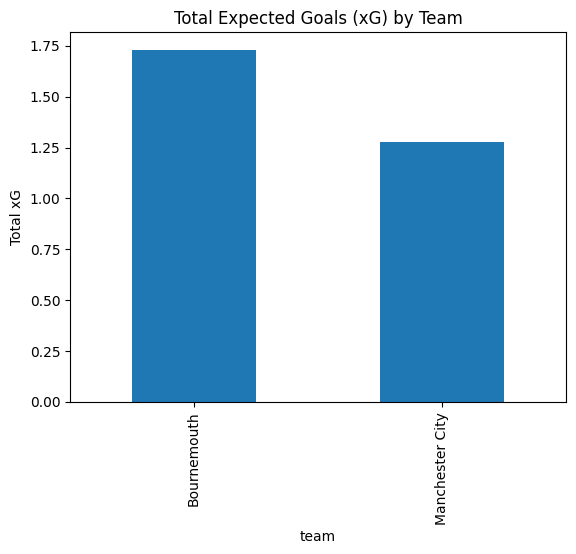

In [ ]:
import matplotlib.pyplot as plt

team_xg.plot(kind="bar")
plt.title("Total Expected Goals (xG) by Team")
plt.ylabel("Total xG")
plt.show()

# Q2: Which players were most efficient in chance conversion?

In [ ]:
import numpy as np

# Create goal column (1 if goal, 0 otherwise)
df["goal"] = df["result"].apply(lambda x: 1 if x == "Goal" else 0)

# Aggregate by player
player_perf = df.groupby("player").agg(
    shots=("id", "count"),
    xG=("xG", "sum"),
    goals=("goal", "sum")
)

# Efficiency metric
player_perf["xG_diff"] = player_perf["goals"] - player_perf["xG"]
player_perf["conversion_rate"] = player_perf["goals"] / player_perf["shots"]

# Sort by efficiency
player_perf = player_perf.sort_values("xG_diff", ascending=False)

player_perf

,shots,xG,goals,xG_diff,conversion_rate
player,,,,,
Erling Haaland,2,0.156985,1,0.843015,0.5
Eli Junior Kroupi,2,0.167480,1,0.832520,0.5
Abduqodir Khusanov,1,0.018072,0,-0.018072,0.0
Antoine Semenyo,1,0.021521,0,-0.021521,0.0
Mathis Cherki,1,0.055019,0,-0.055019,0.0
Bernardo Silva,1,0.080957,0,-0.080957,0.0
Jéremy Doku,1,0.101934,0,-0.101934,0.0
James Hill,1,0.110720,0,-0.110720,0.0
Omar Marmoush,1,0.116502,0,-0.116502,0.0


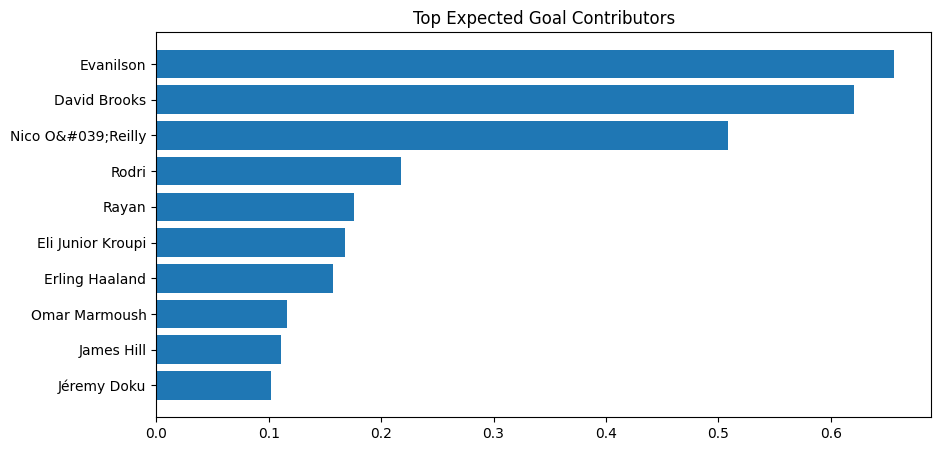

In [ ]:
top = player_perf.sort_values("xG", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(range(len(top)), top["xG"])
plt.yticks(range(len(top)), top.index)
plt.title("Top Expected Goal Contributors")
plt.gca().invert_yaxis()
plt.show()

# From which game situations were most dangerous chances created?

# Aggregate xG by Situation

In [ ]:
situation_xg = df.groupby("situation").agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).sort_values("total_xG", ascending=False)

situation_xg

,total_xG,shots
situation,,
OpenPlay,2.513934,19
FromCorner,0.377229,4
DirectFreekick,0.116502,1


In [ ]:
situation_xg["xG_per_shot"] = situation_xg["total_xG"] / situation_xg["shots"]
situation_xg

,total_xG,shots,xG_per_shot
situation,,,
OpenPlay,2.513934,19,0.132312
FromCorner,0.377229,4,0.094307
DirectFreekick,0.116502,1,0.116502


In [ ]:
team_situation = df.groupby(["team", "situation"]).agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).reset_index()

team_situation.sort_values(["team", "total_xG"], ascending=[True, False])

,team,situation,total_xG,shots
1,Bournemouth,OpenPlay,1.477488,8
0,Bournemouth,FromCorner,0.253138,2
4,Manchester City,OpenPlay,1.036446,11
3,Manchester City,FromCorner,0.124091,2
2,Manchester City,DirectFreekick,0.116502,1


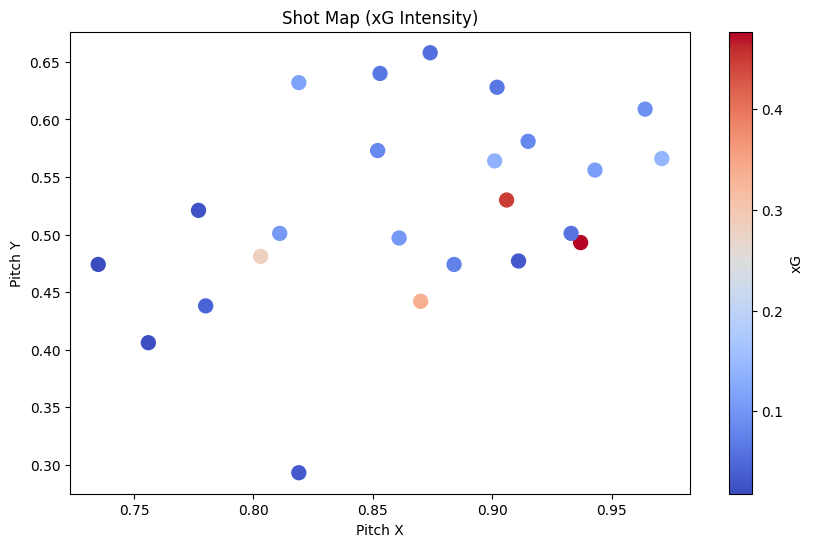

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df["X"], df["Y"], c=df["xG"], cmap="coolwarm", s=100)

plt.title("Shot Map (xG Intensity)")
plt.xlabel("Pitch X")
plt.ylabel("Pitch Y")
plt.colorbar(label="xG")

plt.show()

In [ ]:
player_situation = df.groupby(["team","player", "situation","result"]).agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).reset_index()

player_situation.sort_values("total_xG", ascending=False)

,team,player,situation,result,total_xG,shots
5,Bournemouth,Evanilson,OpenPlay,MissedShots,0.520581,2
17,Manchester City,Nico O&#039;Reilly,OpenPlay,SavedShot,0.447668,1
0,Bournemouth,David Brooks,OpenPlay,SavedShot,0.336200,1
1,Bournemouth,David Brooks,OpenPlay,ShotOnPost,0.284126,1
7,Bournemouth,Rayan,FromCorner,ShotOnPost,0.142418,1
4,Bournemouth,Evanilson,OpenPlay,BlockedShot,0.135844,1
18,Manchester City,Omar Marmoush,DirectFreekick,BlockedShot,0.116502,1
6,Bournemouth,James Hill,FromCorner,BlockedShot,0.110720,1
3,Bournemouth,Eli Junior Kroupi,OpenPlay,MissedShots,0.103907,1
14,Manchester City,Jéremy Doku,OpenPlay,SavedShot,0.101934,1


In [ ]:
player_situation = df.groupby(["team","result"]).agg(
    shots=("id", "count")
).reset_index()

player_situation.sort_values("shots", ascending=False)

,team,result,shots
5,Manchester City,BlockedShot,7
0,Bournemouth,BlockedShot,3
8,Manchester City,SavedShot,3
2,Bournemouth,MissedShots,3
7,Manchester City,MissedShots,2
4,Bournemouth,ShotOnPost,2
1,Bournemouth,Goal,1
3,Bournemouth,SavedShot,1
6,Manchester City,Goal,1
9,Manchester City,ShotOnPost,1


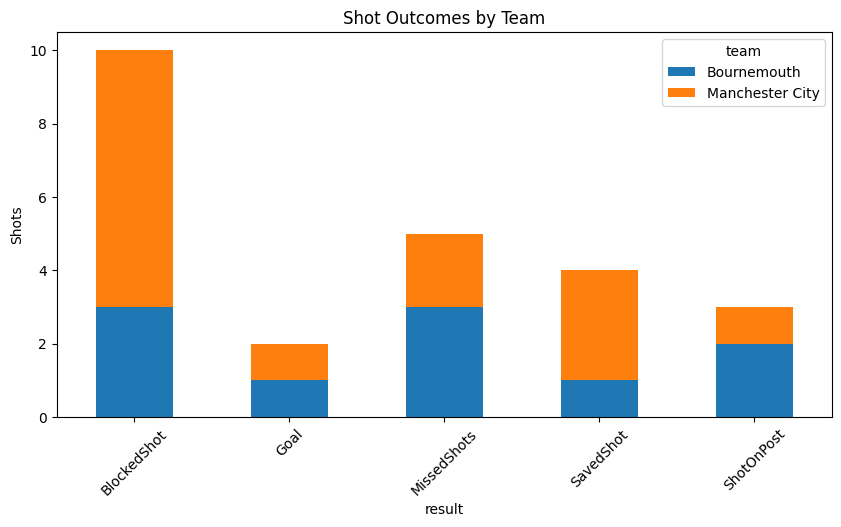

In [ ]:
import matplotlib.pyplot as plt

pivot = player_situation.pivot(index="result", columns="team", values="shots").fillna(0)

pivot.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Shot Outcomes by Team")
plt.ylabel("Shots")
plt.xticks(rotation=45)
plt.show()

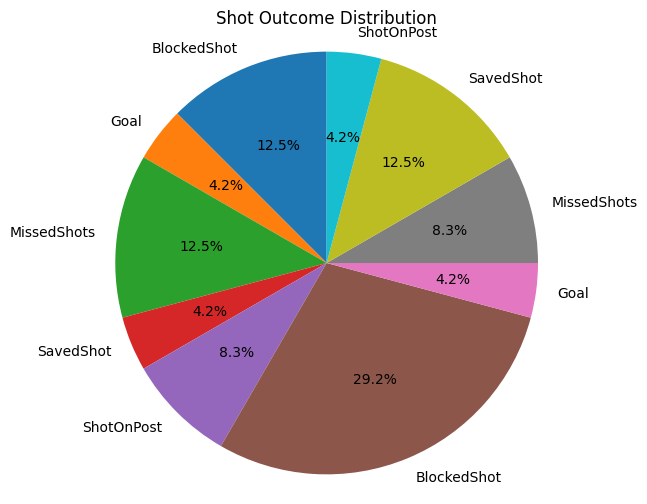

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    player_situation["shots"],
    labels=player_situation["result"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Shot Outcome Distribution")
plt.axis("equal")  # keeps it circular
plt.show()

# Q4: What types of shots generated the highest expected value?

In [ ]:
shottype_xg = df.groupby("shotType").agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).sort_values("total_xG", ascending=False)

shottype_xg

,total_xG,shots
shotType,,
RightFoot,1.407072,11
LeftFoot,1.398000,10
Head,0.202593,3


In [ ]:
shottype_xg["xG_per_shot"] = shottype_xg["total_xG"] / shottype_xg["shots"]
shottype_xg

,total_xG,shots,xG_per_shot
shotType,,,
RightFoot,1.407072,11,0.127916
LeftFoot,1.398000,10,0.139800
Head,0.202593,3,0.067531


# Key Insight
Although right-footed attempts accounted for most shot volume, left-footed shots and headers produced significantly higher average danger per attempt, suggesting the clearest opportunities emerged from structured positional advantages and aerial situations.”

# Q5: Where on the pitch were the most dangerous shots taken?

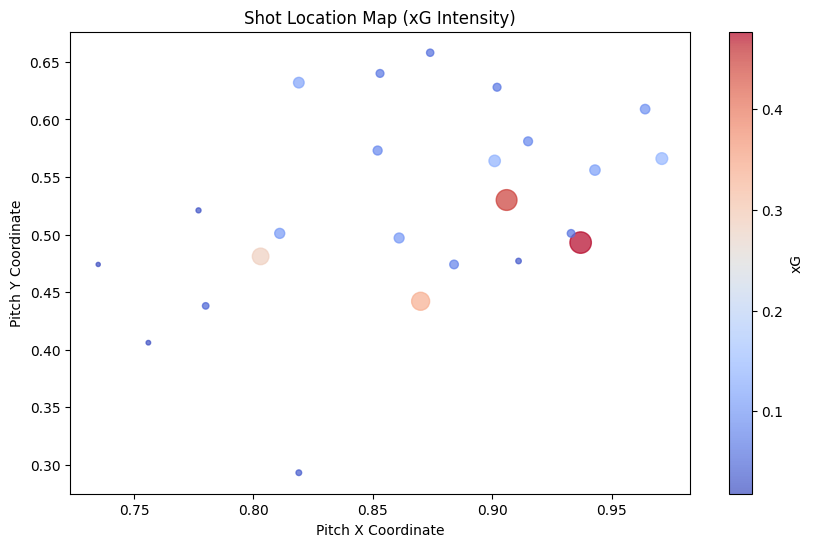

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["X"],
    df["Y"],
    c=df["xG"],
    s=df["xG"] * 500,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Shot Location Map (xG Intensity)")
plt.xlabel("Pitch X Coordinate")
plt.ylabel("Pitch Y Coordinate")

plt.colorbar(label="xG")

plt.show()

In [ ]:
shots_counts= df.groupby(["team","player", "X","Y","xG"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

               team              player      X      Y        xG       result  \
0       Bournemouth        David Brooks  0.803  0.481  0.284126   ShotOnPost   
1       Bournemouth        David Brooks  0.870  0.442  0.336200    SavedShot   
2       Bournemouth   Eli Junior Kroupi  0.811  0.501  0.103907  MissedShots   
3       Bournemouth   Eli Junior Kroupi  0.853  0.640  0.063573         Goal   
4       Bournemouth           Evanilson  0.780  0.438  0.043563  MissedShots   
5       Bournemouth           Evanilson  0.901  0.564  0.135844  BlockedShot   
6       Bournemouth           Evanilson  0.937  0.493  0.477019  MissedShots   
7       Bournemouth          James Hill  0.943  0.556  0.110720  BlockedShot   
8       Bournemouth               Rayan  0.819  0.293  0.033257  BlockedShot   
9       Bournemouth               Rayan  0.971  0.566  0.142418   ShotOnPost   
10  Manchester City  Abduqodir Khusanov  0.735  0.474  0.018072  MissedShots   
11  Manchester City     Antoine Semenyo 

In [ ]:
shots_counts= df.groupby(["team","player", "X","Y","xG","situation"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

               team              player      X      Y        xG  \
0       Bournemouth        David Brooks  0.803  0.481  0.284126   
1       Bournemouth        David Brooks  0.870  0.442  0.336200   
2       Bournemouth   Eli Junior Kroupi  0.811  0.501  0.103907   
3       Bournemouth   Eli Junior Kroupi  0.853  0.640  0.063573   
4       Bournemouth           Evanilson  0.780  0.438  0.043563   
5       Bournemouth           Evanilson  0.901  0.564  0.135844   
6       Bournemouth           Evanilson  0.937  0.493  0.477019   
7       Bournemouth          James Hill  0.943  0.556  0.110720   
8       Bournemouth               Rayan  0.819  0.293  0.033257   
9       Bournemouth               Rayan  0.971  0.566  0.142418   
10  Manchester City  Abduqodir Khusanov  0.735  0.474  0.018072   
11  Manchester City     Antoine Semenyo  0.756  0.406  0.021521   
12  Manchester City      Bernardo Silva  0.915  0.581  0.080957   
13  Manchester City      Erling Haaland  0.902  0.628  0.06428

In [ ]:
pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.7 MB/s eta 0:00:00


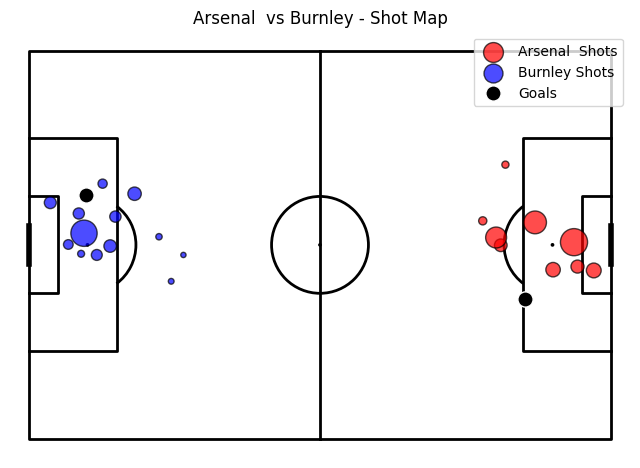

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# Pitch setup
# -----------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Convert coordinates
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# Split teams (IMPORTANT: use .copy())
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# Flip away team coordinates (attacking direction fix)
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# Plot shots by team
# -----------------------------
for d, color, label in [
    (home, 'red', 'Arsenal  Shots'),
    (away, 'blue', 'Burnley Shots')
]:
    ax.scatter(
        d['x'], d['y'],
        s=d['xG'] * 800,
        alpha=0.7,
        c=color,
        edgecolors='black',
        label=label
    )

# -----------------------------
# Highlight goals
# -----------------------------
goals = df[df['result'] == 'Goal'].copy()

# Apply same flip logic for away goals
goals.loc[goals['h_a'] == 'a', 'x'] = 120 - goals.loc[goals['h_a'] == 'a', 'x']
goals.loc[goals['h_a'] == 'a', 'y'] = 80 - goals.loc[goals['h_a'] == 'a', 'y']

ax.scatter(
    goals['x'], goals['y'],
    c='black',
    s=120,
    edgecolors='white',
    label='Goals',
    zorder=3
)

# -----------------------------
# Title + legend
# -----------------------------
plt.title("Arsenal  vs Burnley - Shot Map", fontsize=12)
plt.legend()
plt.show()

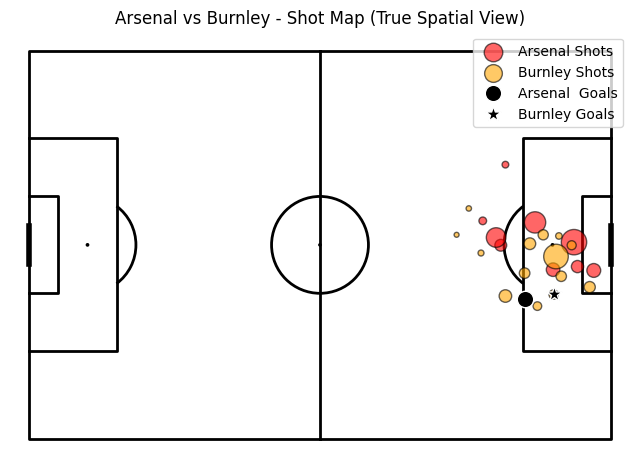

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Convert coordinates
# -----------------------------
df = df.copy()
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# Split teams safely
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# Plot home team
# -----------------------------
ax.scatter(
    home['x'], home['y'],
    s=home['xG'] * 700,
    c='red',
    alpha=0.6,
    edgecolors='black',
    label='Arsenal Shots'
)

# -----------------------------
# Plot away team
# -----------------------------
ax.scatter(
    away['x'], away['y'],
    s=away['xG'] * 700,
    c='orange',
    alpha=0.6,
    edgecolors='black',
    label='Burnley Shots'
)

# -----------------------------
# Goals (kept team-aware)
# -----------------------------
home_goals = home[home['result'] == 'Goal']
away_goals = away[away['result'] == 'Goal']

ax.scatter(
    home_goals['x'], home_goals['y'],
    c='black',
    s=140,
    edgecolors='white',
    zorder=3,
    label='Arsenal  Goals'
)

ax.scatter(
    away_goals['x'], away_goals['y'],
    c='black',
    s=140,
    edgecolors='white',
    marker='*',
    zorder=3,
    label='Burnley Goals'
)

# -----------------------------
# Title + legend
# -----------------------------
plt.title("Arsenal vs Burnley - Shot Map (True Spatial View)", fontsize=12)
plt.legend()
plt.show()

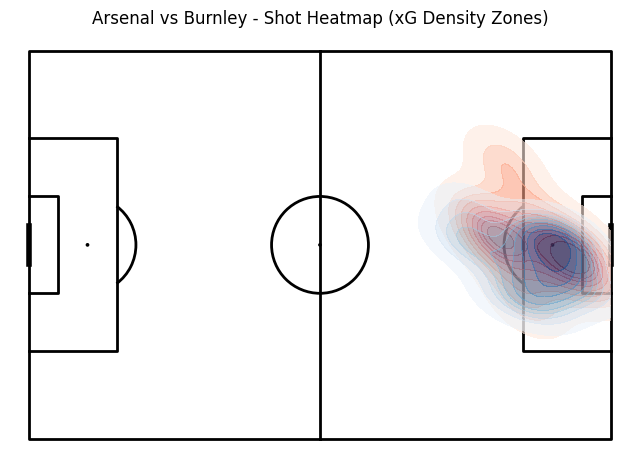

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# Pitch
# -----------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Prepare data
# -----------------------------
df = df.copy()
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

home = df[df['h_a'] == 'h']
away = df[df['h_a'] == 'a']

# -----------------------------
# Heatmap: Home team
# -----------------------------
pitch.kdeplot(
    home['x'],
    home['y'],
    ax=ax,
    fill=True,
    cmap='Reds',
    alpha=0.6,
    label='Home Heatmap'
)

# -----------------------------
# Heatmap: Away team
# -----------------------------
pitch.kdeplot(
    away['x'],
    away['y'],
    ax=ax,
    fill=True,
    cmap='Blues',
    alpha=0.5,
    label='Away Heatmap'
)

# -----------------------------
# Title
# -----------------------------
plt.title("Arsenal vs Burnley - Shot Heatmap (xG Density Zones)")
plt.show()

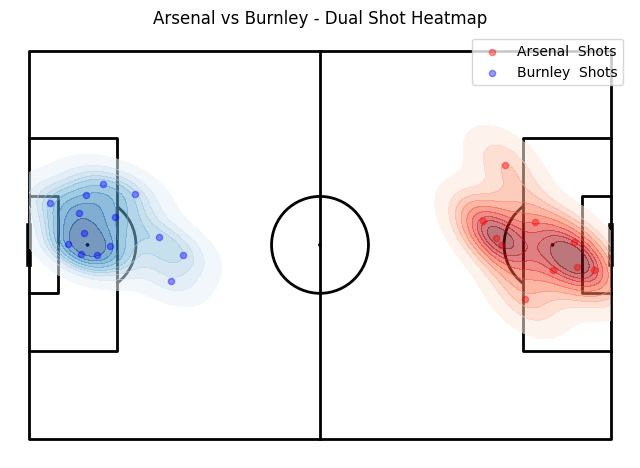

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# Pitch
# -----------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = plt.subplots(figsize=(8, 6))
pitch.draw(ax=ax)

# -----------------------------
# Prepare data
# -----------------------------
df = df.copy()
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# Flip ONLY away team (so both attack same direction visually)
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# Combine for heatmaps per team
# -----------------------------
pitch.kdeplot(
    home['x'],
    home['y'],
    ax=ax,
    fill=True,
    cmap='Reds',
    alpha=0.55
)

pitch.kdeplot(
    away['x'],
    away['y'],
    ax=ax,
    fill=True,
    cmap='Blues',
    alpha=0.55
)

# -----------------------------
# Optional: overlay shot points (for clarity)
# -----------------------------
ax.scatter(home['x'], home['y'], c='red', s=20, alpha=0.4, label='Arsenal  Shots')
ax.scatter(away['x'], away['y'], c='blue', s=20, alpha=0.4, label='Burnley  Shots')

# -----------------------------
# Title + legend
# -----------------------------
plt.title("Arsenal vs Burnley - Dual Shot Heatmap")
plt.legend()
plt.show()

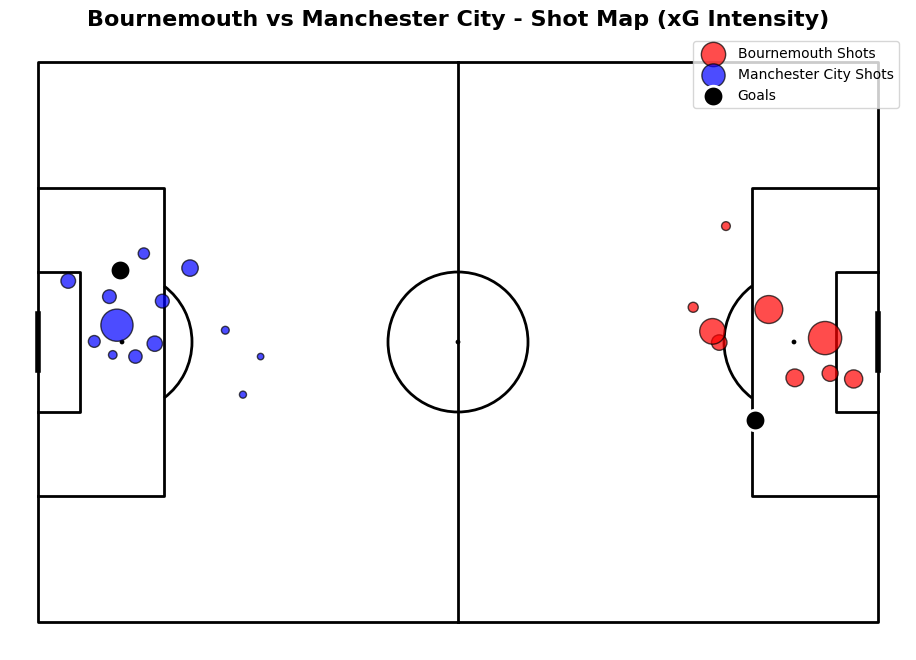

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# -----------------------------
# COPY DATA
# -----------------------------
df = df.copy()

# -----------------------------
# CONVERT UNDERSTAT COORDINATES
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# SPLIT TEAMS
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# FLIP AWAY TEAM
# IMPORTANT
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# TEAM NAMES
# -----------------------------
home_team = df['h_team'].iloc[0]
away_team = df['a_team'].iloc[0]

# -----------------------------
# CREATE PITCH
# -----------------------------
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black'
)

fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

# -----------------------------
# HOME SHOTS
# -----------------------------
ax.scatter(
    home['x'],
    home['y'],
    s=home['xG'] * 1200,
    color='red',
    edgecolors='black',
    alpha=0.7,
    label=f'{home_team} Shots'
)

# -----------------------------
# AWAY SHOTS
# -----------------------------
ax.scatter(
    away['x'],
    away['y'],
    s=away['xG'] * 1200,
    color='blue',
    edgecolors='black',
    alpha=0.7,
    label=f'{away_team} Shots'
)

# -----------------------------
# GOALS
# -----------------------------
goals = df[df['result'] == 'Goal'].copy()

# Flip away goals too
away_goals = goals[goals['h_a'] == 'a'].copy()
away_goals['x'] = 120 - (away_goals['X'] * 120)
away_goals['y'] = 80 - (away_goals['Y'] * 80)

home_goals = goals[goals['h_a'] == 'h'].copy()
home_goals['x'] = home_goals['X'] * 120
home_goals['y'] = home_goals['Y'] * 80

goal_plot = pd.concat([home_goals, away_goals])

ax.scatter(
    goal_plot['x'],
    goal_plot['y'],
    s=220,
    color='black',
    edgecolors='white',
    linewidth=2,
    zorder=5,
    label='Goals'
)

# -----------------------------
# TITLE
# -----------------------------
plt.title(
    f'{home_team} vs {away_team} - Shot Map (xG Intensity)',
    fontsize=16,
    fontweight='bold'
)

plt.legend()
plt.show()

In [ ]:
plt.savefig("shot_map.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
files.download("shot_map.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

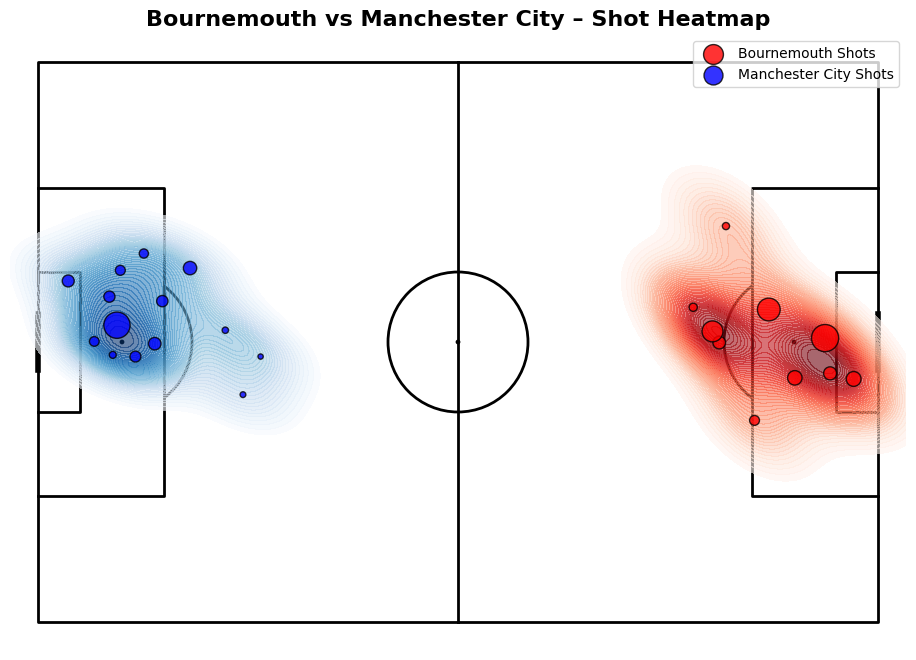

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# COPY DATA
# -----------------------------
df = df.copy()

# -----------------------------
# CONVERT UNDERSTAT COORDINATES
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# SPLIT TEAMS
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# FLIP AWAY TEAM
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# TEAM NAMES
# -----------------------------
home_team = df['h_team'].iloc[0]
away_team = df['a_team'].iloc[0]

# -----------------------------
# CREATE PITCH
# -----------------------------
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black',
    linewidth=2
)

fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

# -----------------------------
# HOME TEAM HEATMAP
# -----------------------------
sns.kdeplot(
    x=home['x'],
    y=home['y'],
    fill=True,
    cmap='Reds',
    alpha=0.6,
    levels=50,
    thresh=0.05,
    ax=ax
)

# -----------------------------
# AWAY TEAM HEATMAP
# -----------------------------
sns.kdeplot(
    x=away['x'],
    y=away['y'],
    fill=True,
    cmap='Blues',
    alpha=0.6,
    levels=50,
    thresh=0.05,
    ax=ax
)

# -----------------------------
# OPTIONAL: ADD SHOT POINTS
# -----------------------------
ax.scatter(
    home['x'],
    home['y'],
    s=home['xG'] * 800,
    color='red',
    edgecolors='black',
    alpha=0.8,
    label=f'{home_team} Shots'
)

ax.scatter(
    away['x'],
    away['y'],
    s=away['xG'] * 800,
    color='blue',
    edgecolors='black',
    alpha=0.8,
    label=f'{away_team} Shots'
)

# -----------------------------
# TITLE
# -----------------------------
plt.title(
    f'{home_team} vs {away_team} – Shot Heatmap',
    fontsize=16,
    fontweight='bold'
)

plt.legend(loc='upper right')
plt.show()

In [ ]:
plt.savefig("heat_map.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
files.download("heat_map.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>